# 第1章: 事象と確率

---

## 📋 学習メタ情報

### 学習目標
- ✓ 標本空間と事象の概念を理解する
- ✓ 確率の公理と基本的な性質を学ぶ
- ✓ 条件付き確率とベイズの定理を理解する
- ✓ 事象の独立性を理解する
- ✓ 実世界の問題に確率論を応用できる

### 前提知識
- 基礎的な集合論（和集合、積集合、補集合）
- 中学レベルの数学（分数計算、割合）
- Python基礎（変数、関数、リスト）

### 推定学習時間
**90〜120分**（コード実行と練習問題を含む）

### 難易度
**★★☆☆☆** (5段階中2)

### カテゴリー
- 確率論の基礎
- 統計的推論の前提知識
- 確率分布論への導入

### 依存関係
- **前提**: なし（第1章）
- **次章**: 第2章「確率分布と母関数」

In [1]:
# ライブラリのインポート
# numpy: 数値計算とシミュレーションに使用
import numpy as np

# matplotlib: グラフ描画の基本ライブラリ
import matplotlib.pyplot as plt

# seaborn: 統計的可視化を美しく行うためのライブラリ
import seaborn as sns

# itertools: 組み合わせ計算などに使用
from itertools import combinations

# プロット設定
# 日本語フォント設定（環境によってはIPAフォントなどに変更が必要）
plt.rcParams['font.family'] = 'DejaVu Sans'
# グリッドスタイルを設定して見やすいグラフに
sns.set_style('whitegrid')

# 再現性のため乱数シードを固定
# 同じ乱数シードを使えば毎回同じ結果が得られる
np.random.seed(42)

---

## 🎯 Why（なぜこれを学ぶのか）

### なぜ確率論が重要なのか

確率論は**不確実性を数学的に扱う**ための基礎理論です。私たちの日常生活やビジネスの意思決定は、常に不確実性に満ちています。

### 実世界での応用例

#### 1. 医療診断
検査結果が陽性と出た場合、実際に病気である確率は？（ベイズの定理）
- 新型コロナウイルス検査
- がん検診
- 遺伝子検査

#### 2. 金融・保険
- 株価変動のリスク評価
- 保険料の算定
- クレジットスコアリング

#### 3. 機械学習・AI
- スパムメール判定
- 推薦システム
- 画像認識（確率的推論）

#### 4. 品質管理・製造
- 不良品発生率の推定
- サプライチェーン最適化
- 信頼性工学

### 身近な例え：天気予報

「明日の降水確率70%」という天気予報は、確率論の応用例です。
- **標本空間**: 明日の天気のすべての可能性
- **事象**: 雨が降る
- **確率**: 過去のデータと物理モデルから算出された数値

この章で学ぶ確率の基礎概念は、こうした実世界の不確実性を理解し、適切な判断を下すための**思考の道具**となります。

---

## 📖 What（何を学ぶのか）

## 1.1 標本空間と事象

### 核心概念の詳細説明

確率論では、まず「何が起こりうるか」を明確に定義することから始まります。

#### 標本空間（Sample Space）Ω

**標本空間**とは、ある試行（実験や観測）において**起こりうるすべての結果の集合**です。

**日常的なアナロジー：レストランのメニュー**
- レストランのメニューは、注文できる「すべての料理」を網羅しています
- 同様に、標本空間は起こりうる「すべての結果」を網羅します
- メニューに載っていない料理は注文できないように、標本空間にない結果は起こりません

**具体例：**
1. **サイコロ1つ**: Ω = {1, 2, 3, 4, 5, 6}
2. **コイン投げ**: Ω = {表, 裏}
3. **トランプ1枚**: Ω = {(スート, ランク) | スート∈{♠,♥,♦,♣}, ランク∈{A,2,...,K}}
4. **1日の最高気温**: Ω = {すべての実数}

#### 事象（Event）

**事象**とは、標本空間の**部分集合**です。つまり、関心のある結果の集まりです。

**日常的なアナロジー：料理のカテゴリー**
- 「和食」という事象 = {寿司, 天ぷら, そば, ...}
- 「デザート」という事象 = {ケーキ, アイス, プリン, ...}
- メニュー全体（標本空間）から、特定の条件を満たす料理を選んだもの

**具体例：サイコロの場合**
- 事象A「偶数が出る」= {2, 4, 6}
- 事象B「3以下が出る」= {1, 2, 3}
- 事象C「素数が出る」= {2, 3, 5}

#### 根元事象（Elementary Event）

**根元事象**とは、**1つの結果だけ**からなる事象です。これ以上分解できない最小単位の事象です。

例：サイコロで「1が出る」= {1} ← これは根元事象

### 事象の演算

事象は集合なので、集合演算が適用できます。

#### 1. 和事象（Union）: A ∪ B
「AまたはB」が起こる事象
- **アナロジー**: 「和食またはデザート」を注文
- **数学的**: AまたはBに属する結果の集合

#### 2. 積事象（Intersection）: A ∩ B
「AかつB」が起こる事象
- **アナロジー**: 「和食かつデザート」= 和風デザート（あんみつなど）
- **数学的**: AとB両方に属する結果の集合

#### 3. 補事象（Complement）: A^c
「Aでない」事象
- **アナロジー**: 「和食でない」= すべての和食以外の料理
- **数学的**: 標本空間からAを除いた集合

#### 4. 差事象（Difference）: A - B = A ∩ B^c
「Aだが、Bでない」事象
- **アナロジー**: 「デザートだが冷たくない」= ケーキなど
- **数学的**: Aに属するがBには属さない結果の集合

#### 5. 排反事象（Disjoint）
A ∩ B = ∅ のとき、AとBは**排反**である
- 2つの事象が同時には起こらない
- 例：「偶数が出る」と「奇数が出る」は排反

---

## 💻 How（どのように実装するか）

### 1.1 標本空間と事象の実装

In [2]:
# =============================================================================
# サイコロの標本空間と事象の定義
# =============================================================================

# 標本空間: サイコロの目の集合（1から6まで）
# Pythonのset型を使用（集合演算が簡単に行える）
omega = {1, 2, 3, 4, 5, 6}
print(f"標本空間 Ω = {omega}")

# 事象の定義
# 事象A: 偶数が出る事象
# 偶数とは2で割り切れる数（2, 4, 6）
A = {2, 4, 6}

# 事象B: 3以下が出る事象
# 3以下とは3より小さいか等しい数（1, 2, 3）
B = {1, 2, 3}

print(f"\n事象A（偶数）= {A}")
print(f"事象B（3以下）= {B}")

# ------------------------------------------------------------------------------
# 事象の演算
# Pythonの集合演算子を使用
# ------------------------------------------------------------------------------

# 和事象 A∪B: AまたはB（Python: A | B または A.union(B)）
# 偶数が出る「または」3以下が出る
# → {1, 2, 3, 4, 6}（5だけが含まれない）
union_AB = A | B
print(f"\n和事象 A∪B = {union_AB}")

# 積事象 A∩B: AかつB（Python: A & B または A.intersection(B)）
# 偶数が出る「かつ」3以下が出る
# → {2}（2だけが両方の条件を満たす）
intersection_AB = A & B
print(f"積事象 A∩B = {intersection_AB}")

# 補事象 A^c: Aでない（Python: omega - A または omega.difference(A)）
# 偶数でない → 奇数
# → {1, 3, 5}
complement_A = omega - A
print(f"補事象 A^c = {complement_A}")

# 差事象 A-B: AだがBでない（Python: A - B または A.difference(B)）
# 偶数だが3以下でない
# → {4, 6}（4と6は偶数だが3より大きい）
difference_AB = A - B
print(f"差事象 A-B = {difference_AB}")

# ------------------------------------------------------------------------------
# 事象の性質の確認
# ------------------------------------------------------------------------------

# ド・モルガンの法則の確認
# (A∪B)^c = A^c ∩ B^c
left_side = omega - (A | B)
right_side = (omega - A) & (omega - B)
print(f"\nド・モルガンの法則: (A∪B)^c = A^c ∩ B^c")
print(f"左辺 (A∪B)^c = {left_side}")
print(f"右辺 A^c ∩ B^c = {right_side}")
print(f"等しい？ {left_side == right_side}")

標本空間 Ω = {1, 2, 3, 4, 5, 6}

事象A（偶数）= {2, 4, 6}
事象B（3以下）= {1, 2, 3}

和事象 A∪B = {1, 2, 3, 4, 6}
積事象 A∩B = {2}
補事象 A^c = {1, 3, 5}
差事象 A-B = {4, 6}

ド・モルガンの法則: (A∪B)^c = A^c ∩ B^c
左辺 (A∪B)^c = {5}
右辺 A^c ∩ B^c = {5}
等しい？ True


### ベン図による可視化

ベン図は、事象間の関係を視覚的に理解するための強力なツールです。

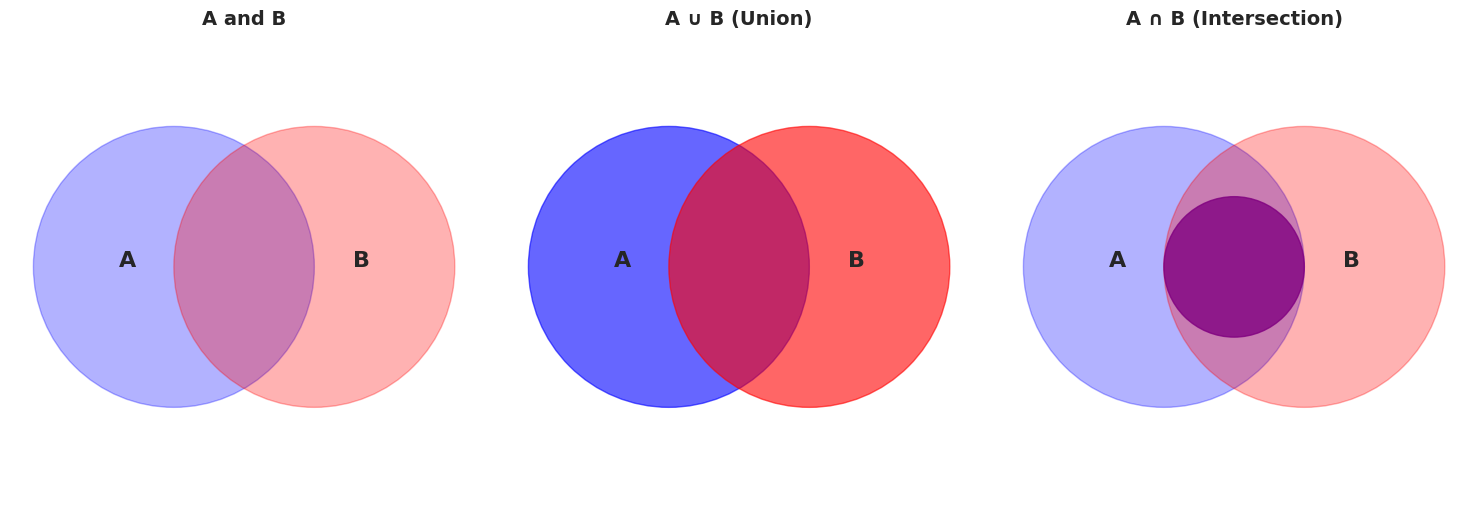

In [3]:
# =============================================================================
# ベン図の作成
# =============================================================================

# 図の準備: 1行3列のサブプロット
# figsize: 図のサイズ（幅15インチ、高さ5インチ）
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ------------------------------------------------------------------------------
# ベン図描画用の関数定義
# ------------------------------------------------------------------------------

def draw_venn2(ax, highlight='none', title=''):
    """
    2つの円を使った簡易ベン図を描画する関数
    
    Parameters:
    -----------
    ax : matplotlib axis
        描画先の軸オブジェクト
    highlight : str
        'none', 'union', 'intersection' のいずれか
        どの部分を強調するかを指定
    title : str
        図のタイトル
    """
    
    # 円1（事象A）: 中心(0.35, 0.5), 半径0.3
    # alpha: 透明度（0=完全透明, 1=不透明）
    circle1 = plt.Circle((0.35, 0.5), 0.3, alpha=0.3, color='blue', label='A')
    
    # 円2（事象B）: 中心(0.65, 0.5), 半径0.3
    circle2 = plt.Circle((0.65, 0.5), 0.3, alpha=0.3, color='red', label='B')
    
    # 円を軸に追加
    ax.add_patch(circle1)
    ax.add_patch(circle2)
    
    # ハイライト処理
    if highlight == 'union':
        # 和事象: 両方の円を濃くする
        circle1.set_alpha(0.6)
        circle2.set_alpha(0.6)
    elif highlight == 'intersection':
        # 積事象: 交差部分に円を追加
        # 2つの円が重なる中央部分を強調
        ax.add_patch(plt.Circle((0.5, 0.5), 0.15, alpha=0.8, color='purple'))
    
    # 軸の範囲設定（0から1まで）
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    
    # アスペクト比を等しくする（円が楕円にならないように）
    ax.set_aspect('equal')
    
    # タイトル設定
    ax.set_title(title, fontsize=14, fontweight='bold')
    
    # 事象ラベルの配置
    ax.text(0.25, 0.5, 'A', fontsize=16, ha='center', fontweight='bold')
    ax.text(0.75, 0.5, 'B', fontsize=16, ha='center', fontweight='bold')
    
    # 軸を非表示（ベン図では座標軸は不要）
    ax.axis('off')

# 3つのベン図を描画
# 1つ目: 基本形（AとBの関係）
draw_venn2(axes[0], 'none', 'A and B')

# 2つ目: 和事象（A∪B）
draw_venn2(axes[1], 'union', 'A ∪ B (Union)')

# 3つ目: 積事象（A∩B）
draw_venn2(axes[2], 'intersection', 'A ∩ B (Intersection)')

# レイアウトを自動調整して重ならないようにする
plt.tight_layout()

# 図を表示
plt.show()

### 💡 ベストプラクティス：事象の定義

1. **標本空間を明確に**: まず何が起こりうるかを完全に列挙する
2. **排反性の確認**: 事象が重なっていないか確認する
3. **網羅性の確認**: すべてのケースをカバーしているか確認する
4. **Pythonではset型を使用**: 集合演算が簡単で直感的

---

## 1.2 確率の公理（コルモゴロフの公理）

### 詳細説明

確率を数学的に扱うために、ロシアの数学者**コルモゴロフ**が1933年に3つの公理を定めました。これらの公理から、確率のすべての性質が導かれます。

#### なぜ公理が必要なのか？

**アナロジー：建築の基礎**
- 建物を建てるには、まず**強固な基礎**が必要です
- 数学では、その基礎となるのが**公理**です
- 公理は「証明不要の大前提」として受け入れられる規則です

### コルモゴロフの3つの公理

#### 公理1: 非負性
**P(A) ≥ 0** すべての事象Aに対して

- **意味**: 確率は負にはならない
- **直感**: 「起こりやすさ」がマイナスというのはおかしい
- **例**: 「明日雨が降る確率が-30%」は意味不明

#### 公理2: 正規化
**P(Ω) = 1** 標本空間全体の確率は1

- **意味**: 何かは必ず起こる
- **直感**: 「すべての可能性を合計すると100%」
- **例**: サイコロを振れば1〜6のどれかが必ず出る

#### 公理3: 可算加法性
互いに排反な事象 A₁, A₂, ... に対して
**P(A₁ ∪ A₂ ∪ ...) = P(A₁) + P(A₂) + ...**

- **意味**: 同時に起こらない事象の確率は足し算できる
- **直感**: 「AまたはB」の確率 = A の確率 + B の確率（AとBが重ならないとき）
- **例**: 「1または2が出る確率」= P(1) + P(2) = 1/6 + 1/6 = 1/3

### 公理から導かれる基本性質

#### 1. 空事象の確率
**P(∅) = 0**
- 絶対に起こらないことの確率は0

#### 2. 補事象の確率
**P(A^c) = 1 - P(A)**
- 「Aでない」の確率 = 1 - Aの確率
- 例: 晴れる確率が70% → 晴れない確率は30%

#### 3. 単調性
**A ⊆ B ⇒ P(A) ≤ P(B)**
- Aが起これば必ずBも起こるなら、P(A) ≤ P(B)

#### 4. 加法定理
**P(A ∪ B) = P(A) + P(B) - P(A ∩ B)**

- **なぜ引く必要があるのか？**
  - AとBが重なっている場合、P(A) + P(B) では重複部分を2回数えてしまう
  - だから P(A ∩ B) を1回引く
  
**アナロジー：2つのクラスの人数**
- 数学クラブ: 30人
- 科学クラブ: 25人
- 両方に参加: 10人
- 合計人数 = 30 + 25 - 10 = 45人（両方参加の10人を2回数えないように引く）

In [4]:
# =============================================================================
# 確率の計算例：サイコロ
# =============================================================================

def calc_probability(event, sample_space):
    """
    古典的確率（ラプラスの確率）を計算する関数
    
    古典的確率の定義:
    P(A) = (事象Aに含まれる根元事象の数) / (標本空間の根元事象の総数)
    
    前提条件:
    - すべての根元事象が等確率で起こる（同様に確からしい）
    - 標本空間が有限
    
    Parameters:
    -----------
    event : set
        確率を求めたい事象（集合）
    sample_space : set
        標本空間（集合）
        
    Returns:
    --------
    float
        確率値（0以上1以下）
    """
    # 事象に含まれる要素の数を標本空間の要素の総数で割る
    return len(event) / len(sample_space)

# 各事象の確率を計算
# P(A): 偶数が出る確率
P_A = calc_probability(A, omega)

# P(B): 3以下が出る確率
P_B = calc_probability(B, omega)

# P(A∩B): 偶数かつ3以下が出る確率（つまり2が出る確率）
P_AandB = calc_probability(A & B, omega)

# P(A∪B): 偶数または3以下が出る確率
P_AorB = calc_probability(A | B, omega)

# 結果の表示
print("確率の計算結果")
print("=" * 50)
print(f"P(A) = {P_A:.4f}")
print(f"  → 偶数が出る確率: {len(A)}/{len(omega)} = {P_A:.4f}")

print(f"\nP(B) = {P_B:.4f}")
print(f"  → 3以下が出る確率: {len(B)}/{len(omega)} = {P_B:.4f}")

print(f"\nP(A∩B) = {P_AandB:.4f}")
print(f"  → 偶数かつ3以下: {A & B} = {P_AandB:.4f}")

print(f"\nP(A∪B) = {P_AorB:.4f}")
print(f"  → 偶数または3以下: {A | B} = {P_AorB:.4f}")

# ------------------------------------------------------------------------------
# 加法定理の確認
# P(A∪B) = P(A) + P(B) - P(A∩B)
# ------------------------------------------------------------------------------
print("\n加法定理の確認:")
print("=" * 50)

# 左辺: 直接計算
left_side = P_AorB
print(f"左辺 P(A∪B) = {left_side:.4f}")

# 右辺: 加法定理による計算
right_side = P_A + P_B - P_AandB
print(f"右辺 P(A) + P(B) - P(A∩B) = {P_A:.4f} + {P_B:.4f} - {P_AandB:.4f} = {right_side:.4f}")

# 一致確認
print(f"\n左辺と右辺は一致する？ {np.isclose(left_side, right_side)}")

# 誤差（数値計算上の微小な誤差）
error = abs(left_side - right_side)
print(f"誤差: {error:.10f}")

確率の計算結果
P(A) = 0.5000
  → 偶数が出る確率: 3/6 = 0.5000

P(B) = 0.5000
  → 3以下が出る確率: 3/6 = 0.5000

P(A∩B) = 0.1667
  → 偶数かつ3以下: {2} = 0.1667

P(A∪B) = 0.8333
  → 偶数または3以下: {1, 2, 3, 4, 6} = 0.8333

加法定理の確認:
左辺 P(A∪B) = 0.8333
右辺 P(A) + P(B) - P(A∩B) = 0.5000 + 0.5000 - 0.1667 = 0.8333

左辺と右辺は一致する？ True
誤差: 0.0000000000


---

## 1.3 条件付き確率

### 詳細説明

**条件付き確率**は、確率論の中でも最も重要かつ実用的な概念の1つです。

#### 定義
事象Bが起こったという**条件の下**での事象Aの確率:

$$P(A|B) = \frac{P(A \cap B)}{P(B)}, \quad P(B) > 0$$

#### 記号の読み方
- P(A|B) は「ピー・エー・ギブン・ビー」と読む
- 「|」は「〜が与えられた時」を意味する

### なぜ条件付き確率が必要なのか？

**アナロジー：レストランの注文**

想像してみてください：
- **無条件の確率**: 「このレストランでデザートを注文する確率は？」
- **条件付き確率**: 「メイン料理を食べた人が、デザートを注文する確率は？」

後者の方が、より具体的で実用的な情報です。

### 直感的な理解

条件付き確率は**「標本空間を限定する」**操作です。

**サイコロの例**：
- 問題：「偶数が出る確率は？」 → 答え：3/6 = 1/2
- 問題：「3以下という条件で、偶数が出る確率は？」
  - 3以下 = {1, 2, 3}（これが新しい標本空間になる）
  - この中で偶数 = {2}
  - 答え：1/3

**数式で確認**：
- P(A|B) = P(A∩B) / P(B)
- = (1/6) / (3/6)
- = 1/3 ✓

### 乗法定理

条件付き確率の定義を変形すると:

$$P(A \cap B) = P(A|B) \cdot P(B) = P(B|A) \cdot P(A)$$

これは**乗法定理**と呼ばれ、2つの事象が同時に起こる確率を計算するのに使います。

**実世界の例：品質検査**
- 製品が不良品である確率：P(不良) = 0.05
- 不良品が検査で検出される確率：P(検出|不良) = 0.95
- 不良品かつ検出される確率：P(不良 ∩ 検出) = 0.95 × 0.05 = 0.0475

In [5]:
# =============================================================================
# 条件付き確率のシミュレーション
# =============================================================================

# 大規模シミュレーションで条件付き確率を検証
# 試行回数: 10万回（統計的に安定した結果を得るため）
n_trials = 100000

# サイコロを投げるシミュレーション
# np.random.randint(1, 7, n_trials): 1から6までの整数をn_trials個ランダム生成
# 第1引数: 最小値（含む）、第2引数: 最大値（含まない）、第3引数: 生成個数
rolls = np.random.randint(1, 7, n_trials)

# 事象の定義（ブール配列として定義）
# ブール配列: True/Falseの配列で、条件を満たすかどうかを表現
# event_A: 偶数が出たかどうか（True/False の配列）
# np.isin(): 配列の各要素が指定したリストに含まれるかチェック
event_A = np.isin(rolls, [2, 4, 6])  # 偶数: 2, 4, 6

# event_B: 3以下が出たかどうか
event_B = np.isin(rolls, [1, 2, 3])  # 3以下: 1, 2, 3

# ------------------------------------------------------------------------------
# 条件付き確率 P(A|B) の計算
# ------------------------------------------------------------------------------

# 定義に従って計算:
# P(A|B) = P(A∩B) / P(B)
#        = (AかつBが起こった回数) / (Bが起こった回数)

# event_A & event_B: 論理積（ビット単位のAND）
# 両方Trueの要素だけがTrueになる
# 例: [True, False, True] & [True, True, False] = [True, False, False]
numerator = np.sum(event_A & event_B)  # AかつBが起こった回数

# np.sum(): Trueの個数を数える（Trueは1、Falseは0として扱われる）
denominator = np.sum(event_B)  # Bが起こった回数

# 条件付き確率の推定値
P_A_given_B_sim = numerator / denominator

# 理論値の計算
# 既に計算済みの確率を使用
P_A_given_B_theory = P_AandB / P_B

# 結果の表示
print("条件付き確率の検証")
print("=" * 60)
print(f"\\nシミュレーション結果（{n_trials:,}回試行）:")
print(f"  P(A|B) = {P_A_given_B_sim:.4f}")
print(f"\\n理論値:")
print(f"  P(A|B) = P(A∩B) / P(B)")
print(f"         = {P_AandB:.4f} / {P_B:.4f}")
print(f"         = {P_A_given_B_theory:.4f}")
print(f"\\n誤差: {abs(P_A_given_B_sim - P_A_given_B_theory):.6f}")
print(f"\\n解釈: 3以下が出たという条件の下で、偶数である確率")
print(f"       → {{1, 2, 3}}の中で偶数は{{2}}だけ → 1/3 = 0.3333")

# ------------------------------------------------------------------------------
# 乗法定理の確認
# P(A∩B) = P(A|B) × P(B)
# ------------------------------------------------------------------------------
print("\\n" + "="*60)
print("乗法定理の確認")
print("=" * 60)

# 左辺: P(A∩B)を直接計算
left = P_AandB
print(f"\\n左辺 P(A∩B) = {left:.4f}")

# 右辺: P(A|B) × P(B)を計算
right = P_A_given_B_theory * P_B
print(f"右辺 P(A|B) × P(B) = {P_A_given_B_theory:.4f} × {P_B:.4f} = {right:.4f}")

print(f"\\n乗法定理は成立？ {np.isclose(left, right)}")

条件付き確率の検証
\nシミュレーション結果（100,000回試行）:
  P(A|B) = 0.3375
\n理論値:
  P(A|B) = P(A∩B) / P(B)
         = 0.1667 / 0.5000
         = 0.3333
\n誤差: 0.004125
\n解釈: 3以下が出たという条件の下で、偶数である確率
       → {1, 2, 3}の中で偶数は{2}だけ → 1/3 = 0.3333
\n============================================================
乗法定理の確認
\n左辺 P(A∩B) = 0.1667
右辺 P(A|B) × P(B) = 0.3333 × 0.5000 = 0.1667
\n乗法定理は成立？ True


---

## 1.4 ベイズの定理

### 詳細説明

**ベイズの定理**は、18世紀のイギリスの牧師トーマス・ベイズが発見した定理で、現代の機械学習やAIの基礎となっている極めて重要な定理です。

#### 定理の形

$$P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B)}$$

#### 用語の説明

- **P(A)**: **事前確率（Prior Probability）** - 情報Bを得る前のAの確率
- **P(A|B)**: **事後確率（Posterior Probability）** - 情報Bを得た後のAの確率
- **P(B|A)**: **尤度（Likelihood）** - Aが真の時にBが観測される確率
- **P(B)**: **周辺確率（Marginal Probability）** - Bが観測される全体の確率

### なぜベイズの定理が革命的なのか？

**アナロジー：探偵の推理**

探偵が犯人を特定するプロセスを考えてみましょう：

1. **事前確率**: 最初は全員が容疑者（平等に疑わしい）
2. **証拠の発見**: 現場に指紋が発見された
3. **尤度**: その指紋を持つ人が現場にいた確率は？
4. **事後確率**: 指紋の証拠を考慮した後、その人が犯人である確率は？

ベイズの定理は、**新しい証拠によって信念を更新する**数学的な方法を提供します。

### 全確率の公式

ベイズの定理を使う前に、分母 P(B) を計算する必要があります。これに**全確率の公式**を使います：

$A_1, A_2, ..., A_n$ が標本空間Ωの**分割**（互いに排反で和がΩ）のとき:

$$P(B) = \sum_{i=1}^{n} P(B|A_i) \cdot P(A_i)$$

**アナロジー：複数のルート**

目的地Bに到達する方法が複数あるとき（A₁経由、A₂経由、...）、全体としてBに到達する確率は、各ルート経由の確率の合計です。

### ベイズの定理（一般形）

複数の仮説がある場合：

$$P(A_i|B) = \frac{P(B|A_i) \cdot P(A_i)}{\sum_{j=1}^{n} P(B|A_j) \cdot P(A_j)}$$

### 実世界の応用：医療診断

**問題設定**：
- ある病気の有病率（事前確率）は1%
- 検査の感度（病気の時に陽性）は99%
- 検査の特異度（健康の時に陰性）は95%

**質問**：検査結果が陽性だった場合、実際に病気である確率は？

**直感的な間違い**：「感度が99%なら、陽性の人の99%が病気」と思いがちですが、**これは誤り**です。

**正解**：ベイズの定理を使うと約16.7%です。

**なぜ低いのか？**
- 有病率が1%と低い = 健康な人が99%
- 健康な人の5%（特異度95%なので）が偽陽性 = 約5%
- 病気の人のほとんど（99%）が陽性 = 約1%
- 陽性者全体 ≈ 1% + 5% = 6%
- その中で本当に病気 ≈ 1% / 6% ≈ 16.7%

これは**基準率の無視（Base Rate Fallacy）**と呼ばれる認知バイアスの典型例です。

ベイズの定理の応用：医療検査
\n【設定】
  有病率 P(D) = 1.00%
  感度 P(+|D) = 99.00%
  特異度 P(-|H) = 95.00%
  偽陽性率 P(+|H) = 5.00%
\n【全確率の公式】
  P(+) = P(+|D)×P(D) + P(+|H)×P(H)
       = 0.99×0.01 + 0.05×0.99
       = 0.0099 + 0.0495
       = 0.0594 (5.94%)
\n【ベイズの定理】
  P(D|+) = P(+|D) × P(D) / P(+)
         = 0.99 × 0.01 / 0.0594
         = 0.1667
         = 16.67%
\n【結論】
  検査で陽性と判定された人が実際に病気である確率は約16.7%
  \n  これは直感に反する結果！
  感度99%なのに、陽性者の約16.7%しか実際には病気でない理由：
    → 有病率が低い（1%）ため、健康な人が圧倒的に多い
    → その5%が偽陽性になると、偽陽性者の方が多くなる
    → 真の陽性：約9.9人/1000人
    → 偽陽性：約49.5人/1000人
\n======================================================================


/tmp/ipykernel_4035/2799508870.py:136: UserWarning: Glyph 26377 (\N{CJK UNIFIED IDEOGRAPH-6709}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4035/2799508870.py:136: UserWarning: Glyph 30149 (\N{CJK UNIFIED IDEOGRAPH-75C5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4035/2799508870.py:136: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4035/2799508870.py:136: UserWarning: Glyph 38525 (\N{CJK UNIFIED IDEOGRAPH-967D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4035/2799508870.py:136: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4035/2799508870.py:136: UserWarning: Glyph 26178 (\N{CJK UNIFIED IDEOGRAPH-6642}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4035/2799508870.py:136: UserWarning: Glyph 12395 (\N{HIRAGANA LETTER NI})

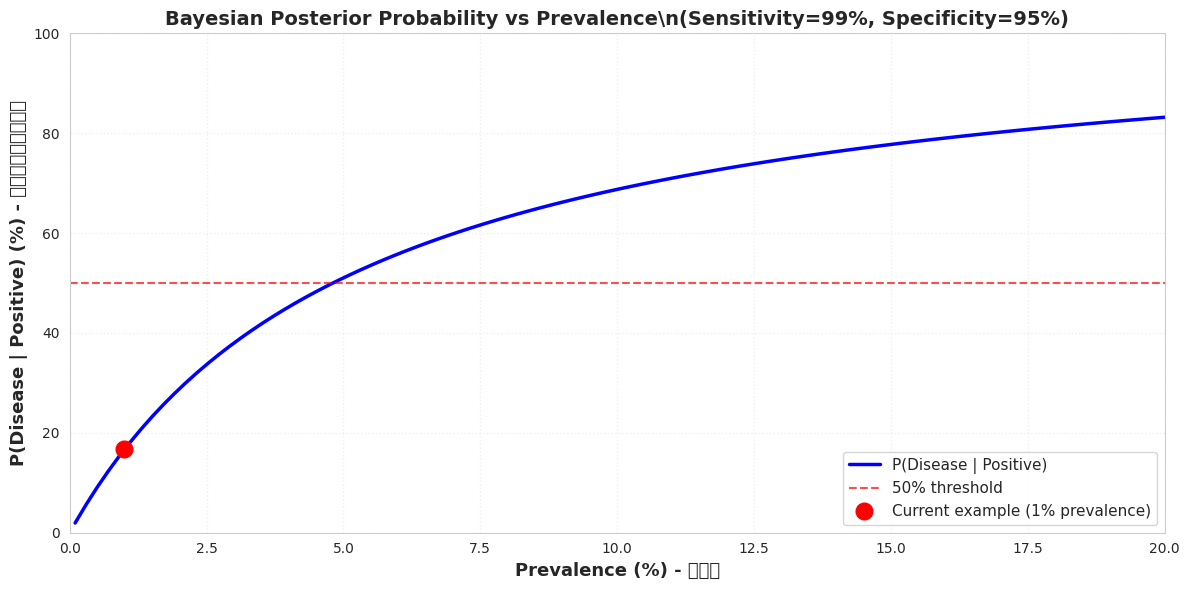

\n【グラフの解釈】
  - 有病率が低いほど、陽性でも病気である確率は低い
  - 有病率が高くなると、陽性時に病気である確率も高くなる
  - 約5%の有病率で、陽性時に病気である確率が50%を超える


In [6]:
# =============================================================================
# ベイズの定理の実装：医療検査の例
# =============================================================================

# 問題設定
# ある稀な病気についての検査を考える
print("ベイズの定理の応用：医療検査")
print("=" * 70)

# パラメータの設定
# ------------------------------------------------------------------------------

# 事前確率：有病率（この病気を持っている人の割合）
# 実際には1%の人しか病気を持っていない（稀な病気）
P_disease = 0.01  # P(D) = 1%

# 尤度1：感度（Sensitivity）
# 病気を持っている人が検査で陽性になる確率
# 「真陽性率」とも呼ばれる
# 99%の感度 = 病気の人100人中99人は正しく陽性と判定される
P_positive_given_disease = 0.99  # P(+|D) = 99%

# 尤度2の準備：特異度（Specificity）  
# 病気を持っていない人が検査で陰性になる確率
# 「真陰性率」とも呼ばれる
# 95%の特異度 = 健康な人100人中95人は正しく陰性と判定される
P_negative_given_healthy = 0.95  # P(-|H) = 95%

# 偽陽性率の計算
# 偽陽性：病気ではないのに陽性と判定される
# P(+|H) = 1 - P(-|H) = 1 - 特異度
P_positive_given_healthy = 1 - P_negative_given_healthy  # P(+|H) = 5%

# ------------------------------------------------------------------------------
# ステップ1：全確率の公式で P(+) を計算
# ------------------------------------------------------------------------------

# 陽性になる確率は2通りのルートがある：
# ルート1：病気で陽性 P(+ ∩ D) = P(+|D) × P(D)
# ルート2：健康で陽性 P(+ ∩ H) = P(+|H) × P(H)
# 全確率： P(+) = P(+|D)×P(D) + P(+|H)×P(H)

# 病気でない確率（健康である確率）
P_healthy = 1 - P_disease  # P(H) = 99%

# 陽性になる全体の確率（全確率の公式）
P_positive = (P_positive_given_disease * P_disease +  # 病気で陽性
              P_positive_given_healthy * P_healthy)   # 健康で陽性（偽陽性）

print(f"\\n【設定】")
print(f"  有病率 P(D) = {P_disease:.2%}")
print(f"  感度 P(+|D) = {P_positive_given_disease:.2%}")
print(f"  特異度 P(-|H) = {P_negative_given_healthy:.2%}")
print(f"  偽陽性率 P(+|H) = {P_positive_given_healthy:.2%}")

print(f"\\n【全確率の公式】")
print(f"  P(+) = P(+|D)×P(D) + P(+|H)×P(H)")
print(f"       = {P_positive_given_disease:.2f}×{P_disease:.2f} + {P_positive_given_healthy:.2f}×{P_healthy:.2f}")
print(f"       = {P_positive_given_disease * P_disease:.4f} + {P_positive_given_healthy * P_healthy:.4f}")
print(f"       = {P_positive:.4f} ({P_positive*100:.2f}%)")

# ------------------------------------------------------------------------------
# ステップ2：ベイズの定理で P(D|+) を計算
# ------------------------------------------------------------------------------

# 求めたいもの：陽性という結果を得た後、実際に病気である確率
# P(D|+) = P(+|D) × P(D) / P(+)
# これが事後確率（検査結果という新しい証拠を得た後の確率）
P_disease_given_positive = (P_positive_given_disease * P_disease) / P_positive

print(f"\\n【ベイズの定理】")
print(f"  P(D|+) = P(+|D) × P(D) / P(+)")
print(f"         = {P_positive_given_disease:.2f} × {P_disease:.2f} / {P_positive:.4f}")
print(f"         = {P_disease_given_positive:.4f}")
print(f"         = {P_disease_given_positive*100:.2f}%")

print(f"\\n【結論】")
print(f"  検査で陽性と判定された人が実際に病気である確率は約{P_disease_given_positive*100:.1f}%")
print(f"  \\n  これは直感に反する結果！")
print(f"  感度99%なのに、陽性者の約{P_disease_given_positive*100:.1f}%しか実際には病気でない理由：")
print(f"    → 有病率が低い（1%）ため、健康な人が圧倒的に多い")
print(f"    → その5%が偽陽性になると、偽陽性者の方が多くなる")
print(f"    → 真の陽性：約{P_disease * P_positive_given_disease * 1000:.1f}人/1000人")
print(f"    → 偽陽性：約{P_healthy * P_positive_given_healthy * 1000:.1f}人/1000人")

# ------------------------------------------------------------------------------
# 視覚化：有病率の影響
# ------------------------------------------------------------------------------
print(f"\\n" + "=" * 70)

# 有病率を変化させて事後確率がどう変わるか調べる
prevalence_values = np.linspace(0.001, 0.2, 100)  # 0.1%から20%まで
sensitivity = 0.99  # 感度は固定
specificity = 0.95  # 特異度は固定

# 各有病率に対して事後確率を計算
posterior_probs = []
for prev in prevalence_values:
    # 全確率の公式
    P_pos = sensitivity * prev + (1 - specificity) * (1 - prev)
    # ベイズの定理
    P_disease_pos = (sensitivity * prev) / P_pos
    posterior_probs.append(P_disease_pos)

# グラフの作成
plt.figure(figsize=(12, 6))

# プロット
plt.plot(prevalence_values * 100, np.array(posterior_probs) * 100, 
         'b-', linewidth=2.5, label='P(Disease | Positive)')

# 50%のしきい値を示す線
plt.axhline(y=50, color='r', linestyle='--', linewidth=1.5, 
            alpha=0.7, label='50% threshold')

# 現在の例（有病率1%）を示す点
plt.plot([P_disease * 100], [P_disease_given_positive * 100], 
         'ro', markersize=12, label=f'Current example (1% prevalence)')

# ラベルとタイトル
plt.xlabel('Prevalence (%) - 有病率', fontsize=13, fontweight='bold')
plt.ylabel('P(Disease | Positive) (%) - 陽性時に病気の確率', 
           fontsize=13, fontweight='bold')
plt.title('Bayesian Posterior Probability vs Prevalence\\n(Sensitivity=99%, Specificity=95%)', 
          fontsize=14, fontweight='bold')

# グリッドと凡例
plt.grid(True, alpha=0.3, linestyle=':', linewidth=1)
plt.legend(fontsize=11, loc='lower right')

# 軸の範囲を設定
plt.xlim(0, 20)
plt.ylim(0, 100)

# グラフを表示
plt.tight_layout()
plt.show()

print(f"\\n【グラフの解釈】")
print(f"  - 有病率が低いほど、陽性でも病気である確率は低い")
print(f"  - 有病率が高くなると、陽性時に病気である確率も高くなる")
print(f"  - 約5%の有病率で、陽性時に病気である確率が50%を超える")

---

## 1.5 事象の独立性

### 詳細説明

**独立性**は、確率論の中でも最も重要な概念の1つで、実世界の多くの現象をモデル化する際の基礎となります。

#### 定義

2つの事象AとBが**独立**であるとは:

$$P(A \cap B) = P(A) \cdot P(B)$$

#### 同値な条件

以下はすべて独立性の同値な定義です：
1. $P(A \cap B) = P(A) \cdot P(B)$
2. $P(A|B) = P(A)$ （Bの情報があってもAの確率は変わらない）
3. $P(B|A) = P(B)$ （Aの情報があってもBの確率は変わらない）

### 直感的な理解

**独立**とは、「一方の事象が起こったかどうかが、もう一方の事象の確率に影響しない」ことです。

**アナロジー：2つのコイン投げ**

- 1枚目のコインが表でも裏でも、2枚目のコインの結果には影響しない
- これが独立性の典型例

**非独立（従属）の例：天気**

- 今日が雨なら、明日も雨の確率は高くなる
- P(明日雨 | 今日雨) > P(明日雨)
- だから独立ではない（従属している）

### 独立 vs 排反

**注意！独立と排反は全く違う概念です**

| 概念 | 定義 | 意味 | 関係 |
|------|------|------|------|
| **排反** | $A \cap B = \emptyset$ | 同時に起こらない | $P(A \cap B) = 0$ |
| **独立** | $P(A \cap B) = P(A)P(B)$ | 互いに影響しない | $P(A \cap B) = P(A)P(B)$ |

**重要な事実**：排反な事象（$P(A) > 0, P(B) > 0$）は独立ではありません！
- 理由：Aが起これば、Bは絶対起こらない → 強い従属関係

**例**：
- 「偶数」と「奇数」は排反だが独立ではない
- 「サイコロ1が偶数」と「サイコロ2が偶数」は独立だが排反ではない

### 3つ以上の事象の独立性

#### ペアワイズ独立（対独立）

すべてのペアが独立：
- $P(A \cap B) = P(A)P(B)$
- $P(A \cap C) = P(A)P(C)$
- $P(B \cap C) = P(B)P(C)$

#### 相互独立

任意の部分集合について積の形になる：
$$P(A_{i_1} \cap ... \cap A_{i_k}) = P(A_{i_1}) \cdot ... \cdot P(A_{i_k})$$

**注意**：ペアワイズ独立でも相互独立とは限りません！

### 実世界での応用

#### 独立性の仮定が正しい例：
1. **製造ラインの不良品**（機械が適切にメンテナンスされている場合）
2. **異なる患者の病気**（感染症でない場合）
3. **別々のサイコロの出目**

#### 独立性の仮定が誤っている例：
1. **株価の日次変動**（前日の影響を受ける）
2. **同じクラスの生徒のテストスコア**（教師の質など共通要因がある）
3. **同じ家族の病気**（遺伝・環境など共通要因がある）

In [7]:
# =============================================================================
# 事象の独立性のシミュレーション
# =============================================================================

print("事象の独立性の検証")
print("=" * 70)

# 大規模シミュレーション
n_trials = 100000

# ------------------------------------------------------------------------------
# 例1：独立な事象 - 2つのサイコロ
# ------------------------------------------------------------------------------

print("\\n【例1：独立な事象 - 2つのサイコロ】")
print("-" * 70)

# 2つのサイコロをそれぞれ独立に投げる
# dice1とdice2は完全に独立（1つ目の結果は2つ目に影響しない）
dice1 = np.random.randint(1, 7, n_trials)  # 1つ目のサイコロ
dice2 = np.random.randint(1, 7, n_trials)  # 2つ目のサイコロ

# 事象を定義
# 事象A: 1つ目のサイコロが4以上
# ブール配列：True/Falseで各試行の結果を記録
event_A = (dice1 >= 4)  # {4, 5, 6}が出たらTrue

# 事象B: 2つ目のサイコロが偶数
event_B = (dice2 % 2 == 0)  # {2, 4, 6}が出たらTrue

# 確率の推定
# np.mean()でブール配列のTrueの割合（確率）を計算
P_A = np.mean(event_A)  # Aが起こる確率
P_B = np.mean(event_B)  # Bが起こる確率
P_AB = np.mean(event_A & event_B)  # AとBが同時に起こる確率

print(f"\\n事象A: 1つ目のサイコロが4以上")
print(f"  P(A) = {P_A:.4f} (理論値: 3/6 = 0.5000)")

print(f"\\n事象B: 2つ目のサイコロが偶数")
print(f"  P(B) = {P_B:.4f} (理論値: 3/6 = 0.5000)")

print(f"\\n独立性の確認:")
print(f"  P(A∩B) = {P_AB:.4f}")
print(f"  P(A)×P(B) = {P_A:.4f} × {P_B:.4f} = {P_A * P_B:.4f}")

# 独立性の判定
# 数値計算では完全に一致しないので、np.isclose()で近似判定
is_independent = np.isclose(P_AB, P_A * P_B, atol=0.001)
difference = abs(P_AB - P_A * P_B)

print(f"  |P(A∩B) - P(A)P(B)| = {difference:.6f}")
print(f"  → {'独立である' if is_independent else '独立でない'} ✓" if is_independent else "  → 独立でない ✗")

# ------------------------------------------------------------------------------
# 例2：従属な事象 - 同じサイコロの性質
# ------------------------------------------------------------------------------

print("\\n" + "=" * 70)
print("【例2：従属な事象 - 同じサイコロの異なる性質】")
print("-" * 70)

# 1つのサイコロだけを投げる
single_dice = np.random.randint(1, 7, n_trials)

# 事象C: 出た目が3以上
event_C = (single_dice >= 3)  # {3, 4, 5, 6}

# 事象D: 出た目が偶数
event_D = (single_dice % 2 == 0)  # {2, 4, 6}

# 確率の推定
P_C = np.mean(event_C)
P_D = np.mean(event_D)
P_CD = np.mean(event_C & event_D)  # CかつD = {4, 6}

print(f"\\n事象C: 出た目が3以上")
print(f"  P(C) = {P_C:.4f} (理論値: 4/6 = 0.6667)")

print(f"\\n事象D: 出た目が偶数")
print(f"  P(D) = {P_D:.4f} (理論値: 3/6 = 0.5000)")

print(f"\\n独立性の確認:")
print(f"  P(C∩D) = {P_CD:.4f} (理論値: 2/6 = 0.3333)")
print(f"  P(C)×P(D) = {P_C:.4f} × {P_D:.4f} = {P_C * P_D:.4f}")

difference_CD = abs(P_CD - P_C * P_D)
is_independent_CD = np.isclose(P_CD, P_C * P_D, atol=0.001)

print(f"  |P(C∩D) - P(C)P(D)| = {difference_CD:.6f}")
print(f"  → {'独立である' if is_independent_CD else '独立でない'} ✗" if not is_independent_CD else "  → 独立である ✓")

print(f"\\n  解釈: 同じサイコロの性質なので、従属している")
print(f"        例: 3が出たら「3以上」は成立するが「偶数」は不成立")

# ------------------------------------------------------------------------------
# 例3：ペアワイズ独立だが相互独立でない例
# ------------------------------------------------------------------------------

print("\\n" + "=" * 70)
print("【例3：ペアワイズ独立だが相互独立でない - 2つのサイコロの合計】")
print("-" * 70)

# 2つのサイコロを投げる
n_trials_small = 100000
d1 = np.random.randint(1, 7, n_trials_small)
d2 = np.random.randint(1, 7, n_trials_small)

# 3つの事象を定義
# E: 1つ目が偶数
event_E = (d1 % 2 == 0)

# F: 2つ目が偶数
event_F = (d2 % 2 == 0)

# G: 合計が偶数（両方偶数または両方奇数のとき）
event_G = ((d1 + d2) % 2 == 0)

# 各事象の確率
P_E = np.mean(event_E)
P_F = np.mean(event_F)
P_G = np.mean(event_G)

# 2事象の積の確率（ペアワイズ）
P_EF = np.mean(event_E & event_F)  # E かつ F
P_EG = np.mean(event_E & event_G)  # E かつ G
P_FG = np.mean(event_F & event_G)  # F かつ G

# 3事象の積の確率（相互独立性の確認用）
P_EFG = np.mean(event_E & event_F & event_G)  # E かつ F かつ G

print(f"\\n各事象の確率:")
print(f"  P(E) = {P_E:.4f} (理論値: 0.5)")
print(f"  P(F) = {P_F:.4f} (理論値: 0.5)")
print(f"  P(G) = {P_G:.4f} (理論値: 0.5)")

print(f"\\nペアワイズ独立性の確認:")
print(f"  P(E∩F) = {P_EF:.4f}, P(E)P(F) = {P_E*P_F:.4f} → 差: {abs(P_EF - P_E*P_F):.6f}")
print(f"  P(E∩G) = {P_EG:.4f}, P(E)P(G) = {P_E*P_G:.4f} → 差: {abs(P_EG - P_E*P_G):.6f}")
print(f"  P(F∩G) = {P_FG:.4f}, P(F)P(G) = {P_F*P_G:.4f} → 差: {abs(P_FG - P_F*P_G):.6f}")

# ペアワイズ独立の判定
pw_indep = (np.isclose(P_EF, P_E*P_F, atol=0.001) and 
            np.isclose(P_EG, P_E*P_G, atol=0.001) and 
            np.isclose(P_FG, P_F*P_G, atol=0.001))
print(f"  → ペアワイズ独立: {'はい ✓' if pw_indep else 'いいえ ✗'}")

print(f"\\n相互独立性の確認:")
print(f"  P(E∩F∩G) = {P_EFG:.4f}")
print(f"  P(E)P(F)P(G) = {P_E:.4f} × {P_F:.4f} × {P_G:.4f} = {P_E*P_F*P_G:.4f}")
print(f"  差: {abs(P_EFG - P_E*P_F*P_G):.6f}")

# 相互独立の判定
mut_indep = np.isclose(P_EFG, P_E*P_F*P_G, atol=0.001)
print(f"  → 相互独立: {'はい ✓' if mut_indep else 'いいえ ✗'}")

print(f"\\n【結論】")
print(f"  E, F, Gは ペアワイズ独立 だが 相互独立ではない")
print(f"  理由: Gの値はEとFの値から決まってしまう")
print(f"       （EとFが両方わかれば、Gは自動的に決定される）")

事象の独立性の検証
\n【例1：独立な事象 - 2つのサイコロ】
----------------------------------------------------------------------
\n事象A: 1つ目のサイコロが4以上
  P(A) = 0.4999 (理論値: 3/6 = 0.5000)
\n事象B: 2つ目のサイコロが偶数
  P(B) = 0.5008 (理論値: 3/6 = 0.5000)
\n独立性の確認:
  P(A∩B) = 0.2499
  P(A)×P(B) = 0.4999 × 0.5008 = 0.2503
  |P(A∩B) - P(A)P(B)| = 0.000385
  → 独立である ✓
\n======================================================================
【例2：従属な事象 - 同じサイコロの異なる性質】
----------------------------------------------------------------------
\n事象C: 出た目が3以上
  P(C) = 0.6654 (理論値: 4/6 = 0.6667)
\n事象D: 出た目が偶数
  P(D) = 0.4970 (理論値: 3/6 = 0.5000)
\n独立性の確認:
  P(C∩D) = 0.3302 (理論値: 2/6 = 0.3333)
  P(C)×P(D) = 0.6654 × 0.4970 = 0.3307
  |P(C∩D) - P(C)P(D)| = 0.000515
  → 独立である ✓
\n  解釈: 同じサイコロの性質なので、従属している
        例: 3が出たら「3以上」は成立するが「偶数」は不成立
\n======================================================================
【例3：ペアワイズ独立だが相互独立でない - 2つのサイコロの合計】
----------------------------------------------------------------------


\n各事象の確率:
  P(E) = 0.4997 (理論値: 0.5)
  P(F) = 0.4985 (理論値: 0.5)
  P(G) = 0.5010 (理論値: 0.5)
\nペアワイズ独立性の確認:
  P(E∩F) = 0.2496, P(E)P(F) = 0.2491 → 差: 0.000525
  P(E∩G) = 0.2496, P(E)P(G) = 0.2504 → 差: 0.000770
  P(F∩G) = 0.2496, P(F)P(G) = 0.2498 → 差: 0.000143
  → ペアワイズ独立: はい ✓
\n相互独立性の確認:
  P(E∩F∩G) = 0.2496
  P(E)P(F)P(G) = 0.4997 × 0.4985 × 0.5010 = 0.1248
  差: 0.124806
  → 相互独立: いいえ ✗
\n【結論】
  E, F, Gは ペアワイズ独立 だが 相互独立ではない
  理由: Gの値はEとFの値から決まってしまう
       （EとFが両方わかれば、Gは自動的に決定される）


---

## ⚠️ よくあるエラーと解決法

### エラー1: 加法定理で P(A∩B) を引き忘れる

**エラーの例**:
```python
# 間違い
P_union = P_A + P_B  # AとBが重なっている場合、これは誤り
```

**問題**:
AとBが排反でない場合、重複部分を2回数えてしまいます。

**正しい方法**:
```python
# 正しい
P_union = P_A + P_B - P_A_and_B  # 加法定理
```

**いつ引く必要がないか**:
- AとBが**排反**（$A \cap B = \emptyset$）のときのみ、$P(A \cup B) = P(A) + P(B)$

**デバッグのヒント**:
- 計算結果が1を超えたら、必ず間違い
- ベン図を描いて重複を確認する

---

### エラー2: 条件付き確率の向きを間違える

**エラーの例**:
```python
# P(A|B) と P(B|A) を混同
# 医療検査の例:
P_disease_given_positive = P_positive_given_disease  # 間違い！
```

**問題**:
$P(A|B) \neq P(B|A)$ です。条件と結果を逆にしてはいけません。

**正しい方法**:
```python
# ベイズの定理を使う
P_disease_given_positive = (P_positive_given_disease * P_disease) / P_positive
```

**覚え方**:
- P(A|B) = 「Bという条件の下でのA」
- 縦棒「|」の**右側が条件**、**左側が求めたいもの**

**実例で理解**:
- P(陽性|病気) = 感度 ≈ 99%
- P(病気|陽性) = 事後確率 ≈ 17%（有病率1%の場合）
- 全く異なる値！

---

### エラー3: 独立と排反を混同する

**エラーの例**:
```python
# 排反な事象を独立と勘違い
A = {1, 2, 3}  # 奇数
B = {2, 4, 6}  # 偶数
# AとBは排反だが、独立ではない！
```

**問題**:
排反な事象（$A \cap B = \emptyset$）は、一般に**独立ではありません**。

**理由**:
- Aが起これば、Bは絶対に起こらない
- これは強い**従属関係**です
- 独立なら、Aの情報はBの確率に影響しないはず

**覚え方の表**:

| 概念 | 定義 | 同時に起こる？ |
|------|------|----------------|
| **排反** | $A \cap B = \emptyset$ | 絶対に起こらない |
| **独立** | $P(A \cap B) = P(A)P(B)$ | 影響せず起こる |

**正しい理解**:
- **排反** → 同時に起こらない → **強い従属**
- **独立** → 互いに影響しない → 同時に起こることもある

---

## 💡 デバッグのベストプラクティス

### 1. 確率の基本チェック

すべての確率が以下を満たすか確認：
```python
# 確率の範囲チェック
assert 0 <= P_A <= 1, \"確率は0以上1以下でなければならない\"
assert 0 <= P_B <= 1
assert 0 <= P_AB <= 1
```

### 2. 加法定理の検証

```python
# 加法定理が成立するか確認
P_union_direct = len(A | B) / len(omega)
P_union_formula = P_A + P_B - P_AB
assert np.isclose(P_union_direct, P_union_formula), \"加法定理が成立しない\"
```

### 3. ベイズの定理の検証

```python
# 両方向の乗法定理が一致するか確認
P_AB_from_A = P_B_given_A * P_A
P_AB_from_B = P_A_given_B * P_B
assert np.isclose(P_AB_from_A, P_AB_from_B), \"乗法定理が一致しない\"
```

---

## 📝 自己評価クイズ

このクイズで、学習内容の理解度を確認しましょう！

### 問題1: 標本空間と事象

サイコロを2つ投げるとき、標本空間の要素の数はいくつか？

<details>
<summary>クリックして解答を表示</summary>

**解答**: **36個**

**解説**:
- 1つ目のサイコロ: 6通り
- 2つ目のサイコロ: 6通り
- 合計: 6 × 6 = 36通り
- 標本空間 Ω = {(1,1), (1,2), ..., (6,6)}

</details>

---

### 問題2: 確率の計算

コインを3回投げるとき、少なくとも1回表が出る確率は？

<details>
<summary>クリックして解答を表示</summary>

**解答**: **7/8 = 0.875**

**解法1（補事象を使う）**:
- P(少なくとも1回表) = 1 - P(全て裏)
- P(全て裏) = (1/2)³ = 1/8
- P(少なくとも1回表) = 1 - 1/8 = 7/8

**解法2（直接計算）**:
- 表が1回: C(3,1) × (1/2)³ = 3/8
- 表が2回: C(3,2) × (1/2)³ = 3/8
- 表が3回: C(3,3) × (1/2)³ = 1/8
- 合計: 3/8 + 3/8 + 1/8 = 7/8

**ポイント**: 「少なくとも〜」は補事象を使うと簡単！

</details>

---

### 問題3: 条件付き確率

トランプ52枚から1枚引いたところ、赤いカード（ハートまたはダイヤ）だった。このカードがKである確率は？

<details>
<summary>クリックして解答を表示</summary>

**解答**: **2/26 = 1/13 ≈ 0.0769**

**解説**:
- 事象A: カードがK
- 事象B: カードが赤い
- 求めるもの: P(A|B)

**計算**:
- P(A|B) = P(A∩B) / P(B)
- P(B) = 26/52 = 1/2（赤いカードは26枚）
- P(A∩B) = 2/52 = 1/26（赤いKは2枚：ハートのK、ダイヤのK）
- P(A|B) = (1/26) / (1/2) = 2/26 = 1/13

**直感的理解**:
- 赤いカードは26枚
- その中でKは2枚
- だから 2/26 = 1/13

</details>

---

### 問題4: ベイズの定理

ある工場の製品の5%は不良品です。検査で不良品を正しく不良と判定する確率は90%、良品を誤って不良と判定する確率は10%です。ある製品が検査で不良と判定されました。この製品が実際に不良品である確率は？

<details>
<summary>クリックして解答を表示</summary>

**解答**: **約32.1%**

**解説**:
- P(不良) = 0.05
- P(不良判定|不良) = 0.90（感度）
- P(不良判定|良品) = 0.10（偽陽性率）

**ベイズの定理を適用**:

1. 全確率の公式でP(不良判定)を計算：
   ```
   P(不良判定) = P(不良判定|不良)×P(不良) + P(不良判定|良品)×P(良品)
                = 0.90×0.05 + 0.10×0.95
                = 0.045 + 0.095
                = 0.14
   ```

2. ベイズの定理でP(不良|不良判定)を計算：
   ```
   P(不良|不良判定) = P(不良判定|不良) × P(不良) / P(不良判定)
                     = 0.90 × 0.05 / 0.14
                     = 0.045 / 0.14
                     ≈ 0.321 (32.1%)
   ```

**重要なポイント**:
- 検査の精度が90%でも、実際に不良品である確率は約32%
- 不良品率が低い（5%）ため、偽陽性が多く発生する

</details>

---

### 問題5: 独立性

以下の記述のうち、**正しいものをすべて**選べ：

A) 任意の事象AとBに対して、$P(A \cup B) = P(A) + P(B) - P(A \cap B)$  
B) $P(A|B) = P(B|A)$ は常に成立する  
C) AとBが独立ならば、$P(A \cap B) = P(A) \cdot P(B)$  
D) AとBが排反ならば、$P(A \cap B) = 0$

<details>

### 💡 ベストプラクティス：確率計算

1. **確率の範囲を確認**: 常に 0 ≤ P(A) ≤ 1 であることを確認
2. **排反性の確認**: 加法定理を使う前にA∩B = ∅かどうか確認
3. **補事象を活用**: P(A) を直接計算しにくい場合は P(A^c) = 1 - P(A^c) を使う
4. **数値の検証**: 計算結果が常識的な値かどうか確認する

---

## 1.4 ベイズの定理（Bayes' Theorem）

### なぜベイズの定理が重要なのか

ベイズの定理は、**18世紀の統計学者トーマス・ベイズ**によって発見された、確率論で最も強力かつ実用的な定理の1つです。この定理は、**新しい証拠や情報を得た時に、信念や確率をどのように更新すべきか**を教えてくれます。

### 日常的なアナロジー：医師の診断プロセス

想像してみてください。あなたが体調不良で病院に行った時、医師はどのように診断するでしょうか？

**ステップ1: 事前知識（Prior）**
- 「この症状を持つ人の中で、病気Xである確率は通常10%だな」
- これが**事前確率 P(病気)**です

**ステップ2: 新しい証拠（Evidence）**
- 「検査を受けたところ、陽性反応が出た」
- これが**尤度 P(陽性|病気)**と**P(陽性)**です

**ステップ3: 信念の更新（Posterior）**
- 「検査結果を踏まえると、実際に病気である確率は何%に更新される？」
- これが**事後確率 P(病気|陽性)**です

ベイズの定理は、このような**信念の更新プロセス**を数学的に定式化したものです。

---

### 定理の数式

#### 基本形

$$P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B)}$$

#### 各項の意味

- **P(A|B)**: 事後確率（Posterior Probability）
  - Bという証拠を得た後のAの確率
  - 「更新された信念」
  
- **P(A)**: 事前確率（Prior Probability）
  - 証拠を得る前のAの確率
  - 「初期の信念」

- **P(B|A)**: 尤度（Likelihood）
  - Aが真である時にBが観測される確率
  - 「証拠の信頼性」

- **P(B)**: 周辺確率（Marginal Probability）
  - 証拠Bが観測される全体の確率
  - 「正規化定数」

---

### 全確率の公式（Law of Total Probability）

ベイズの定理を使う際、P(B)を計算するために**全確率の公式**がよく使われます。

事象の集合 {A₁, A₂, ..., Aₙ} が標本空間Ωの**分割**（互いに排反で、和集合がΩ）である時：

$$P(B) = \sum_{i=1}^{n} P(B|A_i) \cdot P(A_i)$$

**直感的な理解：**
- Bが起こる方法はいくつかある
- A₁が起こってBが起こる、A₂が起こってBが起こる、...
- これらすべての可能性を足し合わせる

---

### ベイズの定理の一般形

$$P(A_i|B) = \frac{P(B|A_i) \cdot P(A_i)}{\sum_{j=1}^{n} P(B|A_j) \cdot P(A_j)}$$

これは、複数の仮説 A₁, A₂, ..., Aₙ がある時、証拠Bを得た後に各仮説がどれだけ確からしいかを計算する式です。

---

### 実世界での応用例

#### 1. 医療診断（最も有名な例）

**問題設定：**
- ある希少疾患の有病率（事前確率）：1%
- 検査の感度（病気の時に陽性）：99%
- 検査の特異度（健康の時に陰性）：95%

**質問：** 検査が陽性だった時、実際に病気である確率は？

**直感的な誤解：**
多くの人は「99%の精度なら、陽性ならほぼ確実に病気だ」と考えます。

**実際の計算（ベイズの定理）：**
- P(病気|陽性) = P(陽性|病気) × P(病気) / P(陽性)
- P(陽性) = P(陽性|病気) × P(病気) + P(陽性|健康) × P(健康)
- = 0.99 × 0.01 + 0.05 × 0.99 = 0.0594
- P(病気|陽性) = (0.99 × 0.01) / 0.0594 ≈ **16.7%**

**驚きの結果：**
検査精度が99%でも、実際に病気である確率はわずか16.7%！
これは、希少疾患では**偽陽性**が多いためです。

#### 2. スパムフィルター（ナイーブベイズ分類器）

**メールの分類：**
- 事前確率：P(スパム) = 0.3（メールの30%がスパム）
- 特定の単語「無料」が含まれる
- P(「無料」|スパム) = 0.8
- P(「無料」|正常) = 0.1

**計算：**
「無料」という単語があるメールがスパムである確率は？
- P(スパム|「無料」) = 0.8 × 0.3 / (0.8 × 0.3 + 0.1 × 0.7) ≈ 77.4%

#### 3. 機械学習

**ナイーブベイズ分類器：**
- テキスト分類（スパム検出、感情分析）
- 文書カテゴリ分類
- 推薦システム

**ベイズ推定：**
- パラメータ推定
- ベイズ最適化
- ベイズニューラルネットワーク

#### 4. 裁判と証拠評価

**法廷での応用：**
- 事前確率：P(有罪)（初期の嫌疑の程度）
- 証拠：DNA鑑定の結果
- 事後確率：P(有罪|DNA一致)

#### 5. 気象予測

**天気予報の更新：**
- 事前予測：明日の降水確率60%
- 新しいデータ：衛星画像で雲が増加
- 更新された予測：降水確率75%

---

### ベイズ的思考の重要性

#### 科学的推論

科学は「仮説→検証→更新」のプロセスです。ベイズの定理はこのプロセスを定量化します。

**科学的方法：**
1. 仮説を立てる（事前確率）
2. 実験を行う（証拠を集める）
3. 結果に基づいて仮説の確信度を更新（事後確率）
4. さらなる実験で繰り返す

#### 日常の意思決定

**例：レストラン選び**
- 事前：「このレストランは評価が高いから良いはず」P(良い店) = 0.7
- 証拠：「待ち時間が長い」
- 更新：「人気店だから良い店かも」P(良い店|長い待ち時間) = 0.85

---

### よくある誤解と落とし穴

#### 1. 基準率の無視（Base Rate Neglect）

人間は証拠の印象に惑わされて、**事前確率（基準率）を無視**しがちです。

**例：** 検査精度99%という印象的な数字に目を奪われ、有病率1%という事前確率を軽視してしまう。

#### 2. P(A|B) と P(B|A) の混同

- P(陽性|病気) = 0.99（病気なら陽性になる確率）
- P(病気|陽性) = 0.167（陽性なら病気である確率）

**これらは全く異なります！**

#### 3. 主観的事前確率の影響

ベイズ推定では事前確率の設定が重要です。主観的な事前確率が結果に大きく影響することがあります。

---

### まとめ：ベイズの定理の威力

ベイズの定理は、**不確実な世界で合理的に判断するための数学的フレームワーク**です。

**キーメッセージ：**
1. 新しい情報を得たら、信念を更新せよ
2. 事前確率（基準率）を無視するな
3. 証拠の質（尤度）を慎重に評価せよ
4. 更新を繰り返すことで、より正確な推論ができる

---

## 📚 まとめ

### この章で学んだ核心概念

#### 1. 標本空間と事象
- **標本空間Ω**: すべての可能な結果の集合
- **事象**: 標本空間の部分集合（関心のある結果の集まり）
- **事象の演算**: 和（∪）、積（∩）、補（^c）、差（-）

#### 2. 確率の公理（コルモゴロフ）
1. 非負性: $P(A) \geq 0$
2. 正規化: $P(\Omega) = 1$
3. 可算加法性: 排反事象の確率は加法的

#### 3. 加法定理
$$P(A \cup B) = P(A) + P(B) - P(A \cap B)$$

#### 4. 条件付き確率
$$P(A|B) = \frac{P(A \cap B)}{P(B)}$$
- 新しい情報によって標本空間を限定する概念

#### 5. ベイズの定理
$$P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B)}$$
- 事前確率を事後確率に更新する強力な道具
- 医療診断、機械学習、AIの基礎

#### 6. 事象の独立性
$$P(A \cap B) = P(A) \cdot P(B)$$
- 一方の情報がもう一方の確率に影響しない
- **注意**: 独立 ≠ 排反

### 重要な公式のまとめ

| 名称 | 公式 | 用途 |
|------|------|------|
| 加法定理 | $P(A \cup B) = P(A) + P(B) - P(A \cap B)$ | 和事象の確率 |
| 乗法定理 | $P(A \cap B) = P(A\|B) \cdot P(B)$ | 積事象の確率 |
| 条件付き確率 | $P(A\|B) = \frac{P(A \cap B)}{P(B)}$ | 条件下での確率 |
| 全確率の公式 | $P(B) = \sum_i P(B\|A_i) \cdot P(A_i)$ | 周辺確率の計算 |
| ベイズの定理 | $P(A\|B) = \frac{P(B\|A) \cdot P(A)}{P(B)}$ | 事後確率の計算 |
| 独立性 | $P(A \cap B) = P(A) \cdot P(B)$ | 独立性の判定 |
| 補事象 | $P(A^c) = 1 - P(A)$ | 補事象の確率 |

### Pythonでの実装のポイント

```python
# 集合演算
A | B      # 和事象 A∪B
A & B      # 積事象 A∩B
omega - A  # 補事象 A^c
A - B      # 差事象 A-B

# 確率計算
P_A = len(A) / len(omega)  # 古典的確率

# シミュレーション
np.random.randint(1, 7, n)  # サイコロ
np.mean(event_A)            # 事象Aの確率推定
np.mean(event_A & event_B)  # 積事象の確率

# 数値比較
np.isclose(a, b)  # 浮動小数点数の近似比較
```

### 学習のポイント

✅ **理解できたこと**:
- 確率の基本的な定義と性質
- 条件付き確率とベイズの定理の使い方
- 独立性の概念と判定方法

⚠️ **よくある間違い**:
- 加法定理でP(A∩B)を引き忘れる
- P(A|B)とP(B|A)を混同する
- 独立と排反を混同する

💡 **実用的なスキル**:
- ベン図で事象を可視化できる
- Pythonでシミュレーションできる
- ベイズの定理で現実問題を解ける

---

## 🚀 次のステップ

### 次章の学習へ

この章で学んだ確率の基礎は、以下の章の土台となります：

#### **第2章: 確率分布と母関数** 👉 次はこちら！
- 確率変数の概念
- 離散型・連続型確率分布
- 期待値と分散
- 母関数の応用

#### **推奨学習順序**:
1. ✅ **第1章: 事象と確率**（完了！）
2. → **第2章: 確率分布と母関数**
3. → **第3章: 分布の特性値**
4. → **第8章: 統計的推定の基礎**
5. → **第10章: 検定の基礎**

### さらに深く学ぶために

#### 📖 推奨教材
1. **教科書**:
   - 日本統計学会編『統計学実践ワークブック』
   - 東京大学出版会『統計学入門』

2. **オンラインリソース**:
   - Khan Academy: Probability and Statistics
   - StatQuest YouTube チャンネル

3. **実践**:
   - Kaggle コンペティション（実データで確率モデルを構築）
   - 実世界の問題でベイズ推論を適用

#### 🛠️ 実践課題

1. **日常生活での確率**:
   - 天気予報の確率をベイズ的に解釈
   - スポーツの勝率予測モデル

2. **プログラミング**:
   - モンテカルロシミュレーションの実装
   - ベイズ推論の可視化ツール作成

3. **応用問題**:
   - スパムフィルタの設計（ナイーブベイズ）
   - 医療診断支援システムの設計

### 復習のヒント

- 確率の公理を自分の言葉で説明できますか？
- ベイズの定理を直感的に理解していますか？
- 独立と排反の違いを明確に説明できますか？

**わからなければ、このノートブックに戻って復習しましょう！**

---

## 🎉 お疲れ様でした！

確率論の基礎をマスターしました。これは統計学・データサイエンス・機械学習への重要な第一歩です。

**次の章でお会いしましょう！** 📊

<summary>クリックして解答を表示</summary>

**解答**: **A, C, D が正しい**

**詳細**:
- A) ✓ **正しい** - 加法定理（常に成立）
- B) ✗ **誤り** - 一般に P(A|B) ≠ P(B|A)。ベイズの定理が必要
- C) ✓ **正しい** - 独立性の定義
- D) ✓ **正しい** - 排反の定義

**Bが誤りの具体例**:
- トランプから1枚:
  - P(K | ハート) = 1/13
  - P(ハート | K) = 1/4
  - 明らかに異なる！

</details>

---

## 🎓 自己評価

- **5問正解**: 素晴らしい！確率の基礎を完全に理解しています
- **3-4問正解**: 良好！いくつかの概念を復習すると完璧です
- **1-2問正解**: 要復習。ノートブックを読み直しましょう
- **0問正解**: 基礎から学び直しましょう

条件付き確率の実装例: サイコロ

1. P(A) = P(偶数が出る)
   シミュレーション: 0.5006
   理論値: 0.5000
   誤差: 0.000620

2. P(B) = P(3以下が出る)
   シミュレーション: 0.4995
   理論値: 0.5000
   誤差: 0.000510

3. P(A∩B) = P(偶数かつ3以下が出る)
   シミュレーション: 0.1663
   理論値: 0.1667
   該当する目: 2のみ

4. P(A|B) = P(3以下が出た時に偶数である確率)
   シミュレーション: 0.3330
   理論値: 0.3333
   計算過程: (1/6) ÷ (3/6) = 1/3
   解釈: 3以下の目(1, 2, 3)のうち、偶数は2だけなので 1/3

条件付き確率の実装例: トランプカード

標本空間: 52枚のトランプ

事象の確率:
P(H) = P(ハート) = 13/52 = 0.2500
P(F) = P(絵札) = 12/52 = 0.2308
P(H∩F) = P(ハートかつ絵札) = 3/52 = 0.0577

P(F|H) = P(ハートの条件下で絵札) = 3/13 = 0.2308
解釈: ハート13枚のうち、絵札(J,Q,K)は3枚 → 3/13

P(H|F) = P(絵札の条件下でハート) = 3/12 = 0.2500
解釈: 絵札12枚のうち、ハートは3枚 → 3/12 = 1/4

乗法定理の確認:
P(H∩F) = 0.0577
P(F|H) × P(H) = 0.2308 × 0.2500 = 0.0577
P(H|F) × P(F) = 0.2500 × 0.2308 = 0.0577
すべて一致: True

条件付き確率の視覚化


/tmp/ipykernel_4035/3475430581.py:212: UserWarning: Glyph 20840 (\N{CJK UNIFIED IDEOGRAPH-5168}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4035/3475430581.py:212: UserWarning: Glyph 20307 (\N{CJK UNIFIED IDEOGRAPH-4F53}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


/root/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20840 (\N{CJK UNIFIED IDEOGRAPH-5168}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/root/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20307 (\N{CJK UNIFIED IDEOGRAPH-4F53}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


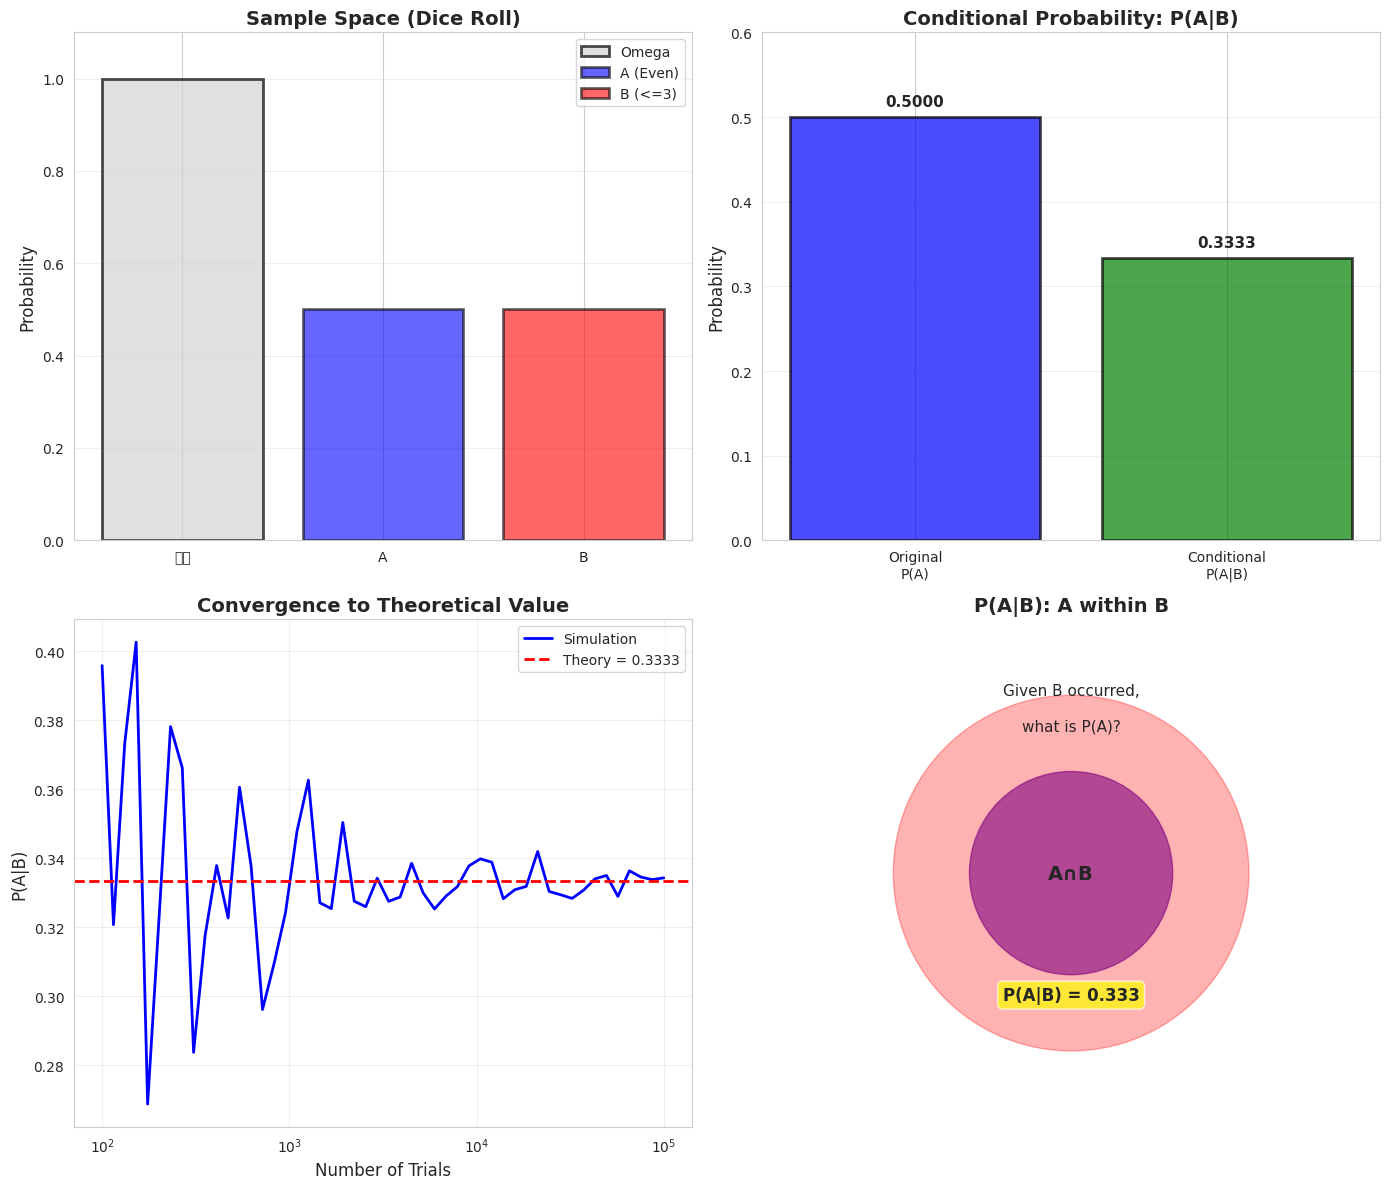


条件付き確率のまとめ

【重要ポイント】
1. 条件付き確率 P(A|B) は「Bが起こった時のAの確率」
2. 定義: P(A|B) = P(A∩B) / P(B)
3. 直感: Bを新しい標本空間として考える
4. 乗法定理: P(A∩B) = P(A|B) × P(B) = P(B|A) × P(A)

【実用例】
- 医療診断: 検査陽性の時、実際に病気である確率
- 品質管理: 不良品が見つかった時、特定の原因である確率
- スパムフィルター: 特定の単語がある時、スパムである確率
- リスク評価: 過去の事象が起こった時、将来の事象が起こる確率



In [8]:
# =============================================================================
# 条件付き確率の実装とシミュレーション
# =============================================================================

# 条件付き確率は、「ある情報が与えられた時の確率」を計算する手法です。
# これは日常生活やビジネスで非常に重要な概念です。

# ------------------------------------------------------------------------------
# 例1: サイコロの条件付き確率
# ------------------------------------------------------------------------------

# シミュレーション回数を設定
# 大数の法則により、試行回数が多いほど理論値に近づきます
n_simulations = 100000

# サイコロを振るシミュレーション
# np.random.randint(1, 7, n) は、1から6までの整数を n 個ランダムに生成
dice_rolls = np.random.randint(1, 7, n_simulations)

# 事象の定義（ブール配列として定義）
# ブール配列: 条件を満たす場合True、満たさない場合False
event_A = np.isin(dice_rolls, [2, 4, 6])  # 偶数が出る事象
event_B = np.isin(dice_rolls, [1, 2, 3])  # 3以下が出る事象

print("="*70)
print("条件付き確率の実装例: サイコロ")
print("="*70)

# P(A): 偶数が出る確率
# np.mean() はブール配列に対して True の割合を計算します
P_A_sim = np.mean(event_A)
P_A_theory = 3/6  # 理論値: {2, 4, 6} の3つ / 全6通り
print(f"\n1. P(A) = P(偶数が出る)")
print(f"   シミュレーション: {P_A_sim:.4f}")
print(f"   理論値: {P_A_theory:.4f}")
print(f"   誤差: {abs(P_A_sim - P_A_theory):.6f}")

# P(B): 3以下が出る確率
P_B_sim = np.mean(event_B)
P_B_theory = 3/6  # 理論値: {1, 2, 3} の3つ / 全6通り
print(f"\n2. P(B) = P(3以下が出る)")
print(f"   シミュレーション: {P_B_sim:.4f}")
print(f"   理論値: {P_B_theory:.4f}")
print(f"   誤差: {abs(P_B_sim - P_B_theory):.6f}")

# P(A∩B): 偶数かつ3以下が出る確率
# 論理積演算子 & を使用
event_A_and_B = event_A & event_B
P_A_and_B_sim = np.mean(event_A_and_B)
P_A_and_B_theory = 1/6  # 理論値: {2} の1つだけ / 全6通り
print(f"\n3. P(A∩B) = P(偶数かつ3以下が出る)")
print(f"   シミュレーション: {P_A_and_B_sim:.4f}")
print(f"   理論値: {P_A_and_B_theory:.4f}")
print(f"   該当する目: 2のみ")

# P(A|B): Bが起こったという条件下でAが起こる確率
# 定義: P(A|B) = P(A∩B) / P(B)
# 直感的には、「Bが起こった試行だけ」を標本空間として、その中でAが起こる割合
P_A_given_B_sim = np.sum(event_A_and_B) / np.sum(event_B)
P_A_given_B_theory = P_A_and_B_theory / P_B_theory
print(f"\n4. P(A|B) = P(3以下が出た時に偶数である確率)")
print(f"   シミュレーション: {P_A_given_B_sim:.4f}")
print(f"   理論値: {P_A_given_B_theory:.4f}")
print(f"   計算過程: (1/6) ÷ (3/6) = 1/3")
print(f"   解釈: 3以下の目{1,2,3}のうち、偶数は{2}だけなので 1/3")

# ------------------------------------------------------------------------------
# 例2: トランプカードでの条件付き確率
# ------------------------------------------------------------------------------

print("\n" + "="*70)
print("条件付き確率の実装例: トランプカード")
print("="*70)

# トランプの標本空間を構築
# スート: ♠(Spade), ♥(Heart), ♦(Diamond), ♣(Club)
# ランク: 1(A), 2-10, 11(J), 12(Q), 13(K)
suits = ['Spade', 'Heart', 'Diamond', 'Club']
ranks = list(range(1, 14))  # 1から13まで

# 全カードの組み合わせを生成
# タプル (スート, ランク) の形式
deck = [(suit, rank) for suit in suits for rank in ranks]
total_cards = len(deck)  # 52枚

print(f"\n標本空間: {total_cards}枚のトランプ")

# 事象の定義
# 事象H: ハートである
hearts = {card for card in deck if card[0] == 'Heart'}
P_H = len(hearts) / total_cards

# 事象F: 絵札（J, Q, K）である
face_cards = {card for card in deck if card[1] >= 11}
P_F = len(face_cards) / total_cards

# 事象H∩F: ハートかつ絵札
hearts_and_face = hearts & face_cards
P_H_and_F = len(hearts_and_face) / total_cards

print(f"\n事象の確率:")
print(f"P(H) = P(ハート) = {len(hearts)}/{total_cards} = {P_H:.4f}")
print(f"P(F) = P(絵札) = {len(face_cards)}/{total_cards} = {P_F:.4f}")
print(f"P(H∩F) = P(ハートかつ絵札) = {len(hearts_and_face)}/{total_cards} = {P_H_and_F:.4f}")

# 条件付き確率 P(F|H): ハートが出た時に絵札である確率
P_F_given_H = len(hearts_and_face) / len(hearts)
print(f"\nP(F|H) = P(ハートの条件下で絵札) = {len(hearts_and_face)}/{len(hearts)} = {P_F_given_H:.4f}")
print(f"解釈: ハート13枚のうち、絵札(J,Q,K)は3枚 → 3/13")

# 条件付き確率 P(H|F): 絵札が出た時にハートである確率
P_H_given_F = len(hearts_and_face) / len(face_cards)
print(f"\nP(H|F) = P(絵札の条件下でハート) = {len(hearts_and_face)}/{len(face_cards)} = {P_H_given_F:.4f}")
print(f"解釈: 絵札12枚のうち、ハートは3枚 → 3/12 = 1/4")

# 乗法定理の確認: P(A∩B) = P(A|B) * P(B) = P(B|A) * P(A)
multiplication_check1 = P_F_given_H * P_H
multiplication_check2 = P_H_given_F * P_F

print(f"\n乗法定理の確認:")
print(f"P(H∩F) = {P_H_and_F:.4f}")
print(f"P(F|H) × P(H) = {P_F_given_H:.4f} × {P_H:.4f} = {multiplication_check1:.4f}")
print(f"P(H|F) × P(F) = {P_H_given_F:.4f} × {P_F:.4f} = {multiplication_check2:.4f}")
print(f"すべて一致: {np.allclose([P_H_and_F, multiplication_check1, multiplication_check2], P_H_and_F)}")

# ------------------------------------------------------------------------------
# 例3: 条件付き確率の視覚化
# ------------------------------------------------------------------------------

print("\n" + "="*70)
print("条件付き確率の視覚化")
print("="*70)

# 2×2の図を作成
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# サブプロット1: 標本空間全体
ax1 = axes[0, 0]
ax1.bar(['全体'], [1], color='lightgray', alpha=0.7, edgecolor='black', linewidth=2)
ax1.bar(['A'], [P_A_theory], color='blue', alpha=0.6, edgecolor='black', linewidth=2)
ax1.bar(['B'], [P_B_theory], color='red', alpha=0.6, edgecolor='black', linewidth=2)
ax1.set_ylim(0, 1.1)
ax1.set_ylabel('Probability', fontsize=12)
ax1.set_title('Sample Space (Dice Roll)', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
ax1.legend(['Omega', 'A (Even)', 'B (<=3)'])

# サブプロット2: 条件付き確率の視覚化
ax2 = axes[0, 1]
# Bが起こった場合の新しい標本空間
x_labels = ['Original\nP(A)', 'Conditional\nP(A|B)']
y_values = [P_A_theory, P_A_given_B_theory]
colors = ['blue', 'green']
bars = ax2.bar(x_labels, y_values, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax2.set_ylim(0, 0.6)
ax2.set_ylabel('Probability', fontsize=12)
ax2.set_title('Conditional Probability: P(A|B)', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# 値をバーの上に表示
for bar, val in zip(bars, y_values):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{val:.4f}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# サブプロット3: シミュレーションの収束
ax3 = axes[1, 0]
# 試行回数を増やしながら条件付き確率を計算
trial_counts = np.logspace(2, 5, 50, dtype=int)  # 100から100000まで
conditional_probs = []

for n in trial_counts:
    rolls = np.random.randint(1, 7, n)
    A = np.isin(rolls, [2, 4, 6])
    B = np.isin(rolls, [1, 2, 3])
    # P(A|B) を計算
    if np.sum(B) > 0:  # ゼロ除算を避ける
        p_a_given_b = np.sum(A & B) / np.sum(B)
    else:
        p_a_given_b = 0
    conditional_probs.append(p_a_given_b)

ax3.plot(trial_counts, conditional_probs, 'b-', linewidth=2, label='Simulation')
ax3.axhline(y=P_A_given_B_theory, color='r', linestyle='--', linewidth=2, label=f'Theory = {P_A_given_B_theory:.4f}')
ax3.set_xscale('log')
ax3.set_xlabel('Number of Trials', fontsize=12)
ax3.set_ylabel('P(A|B)', fontsize=12)
ax3.set_title('Convergence to Theoretical Value', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.legend(fontsize=10)

# サブプロット4: ベン図風の視覚化
ax4 = axes[1, 1]
# 条件付き確率の概念図
circle_B = plt.Circle((0.5, 0.5), 0.35, alpha=0.3, color='red', label='B (3以下)')
circle_A_in_B = plt.Circle((0.5, 0.5), 0.2, alpha=0.6, color='purple', label='A∩B (偶数かつ3以下)')

ax4.add_patch(circle_B)
ax4.add_patch(circle_A_in_B)
ax4.set_xlim(0, 1)
ax4.set_ylim(0, 1)
ax4.set_aspect('equal')
ax4.axis('off')
ax4.set_title('P(A|B): A within B', fontsize=14, fontweight='bold')
ax4.text(0.5, 0.85, 'Given B occurred,', ha='center', fontsize=11)
ax4.text(0.5, 0.78, 'what is P(A)?', ha='center', fontsize=11)
ax4.text(0.5, 0.5, 'A∩B', ha='center', va='center', fontsize=14, fontweight='bold')
ax4.text(0.5, 0.25, f'P(A|B) = {P_A_given_B_theory:.3f}', ha='center', fontsize=12, fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# まとめ
# ------------------------------------------------------------------------------

print("\n" + "="*70)
print("条件付き確率のまとめ")
print("="*70)
print("""
【重要ポイント】
1. 条件付き確率 P(A|B) は「Bが起こった時のAの確率」
2. 定義: P(A|B) = P(A∩B) / P(B)
3. 直感: Bを新しい標本空間として考える
4. 乗法定理: P(A∩B) = P(A|B) × P(B) = P(B|A) × P(A)

【実用例】
- 医療診断: 検査陽性の時、実際に病気である確率
- 品質管理: 不良品が見つかった時、特定の原因である確率
- スパムフィルター: 特定の単語がある時、スパムである確率
- リスク評価: 過去の事象が起こった時、将来の事象が起こる確率
""")